# plotting wind using isohytes

In [1]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [2]:
# load the dataset
ds = xr.open_dataset('./wrfout_d01_2026-03-20_06:00:00')

In [3]:
print(ds)

<xarray.Dataset> Size: 1GB
Dimensions:                (Time: 25, south_north: 129, west_east: 119,
                            bottom_top: 44, bottom_top_stag: 45,
                            soil_layers_stag: 4, west_east_stag: 120,
                            south_north_stag: 130, seed_dim_stag: 8)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 2MB ...
    XLONG                  (Time, south_north, west_east) float32 2MB ...
    XTIME                  (Time) datetime64[ns] 200B ...
    XLAT_U                 (Time, south_north, west_east_stag) float32 2MB ...
    XLONG_U                (Time, south_north, west_east_stag) float32 2MB ...
    XLAT_V                 (Time, south_north_stag, west_east) float32 2MB ...
    XLONG_V                (Time, south_north_stag, west_east) float32 2MB ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                     

In [4]:
# extracting wind components and coordinates
u = ds.U10.isel(Time=0)  # U Eastward component of wind at 10m
v = ds.V10.isel(Time=0)  # V Northward component of wind at 10m
lon = ds.XLONG.isel(Time=0)
lat = ds.XLAT.isel(Time=0)

In [5]:
print(u)

<xarray.DataArray 'U10' (south_north: 129, west_east: 119)> Size: 61kB
[15351 values with dtype=float32]
Coordinates:
    XLAT     (south_north, west_east) float32 61kB ...
    XLONG    (south_north, west_east) float32 61kB ...
    XTIME    datetime64[ns] 8B ...
Dimensions without coordinates: south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  U at 10 M
    units:        m s-1
    stagger:      


In [6]:
print(lon)

<xarray.DataArray 'XLONG' (south_north: 129, west_east: 119)> Size: 61kB
[15351 values with dtype=float32]
Coordinates:
    XLAT     (south_north, west_east) float32 61kB ...
    XLONG    (south_north, west_east) float32 61kB ...
    XTIME    datetime64[ns] 8B ...
Dimensions without coordinates: south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  LONGITUDE, WEST IS NEGATIVE
    units:        degree_east
    stagger:      


In [7]:
# 1. CONVERSION: Convert m/s to Knots
u_knots = u * 1.94384
v_knots = v * 1.94384

/home/erickwambugu/miniconda3/envs/wrf_venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


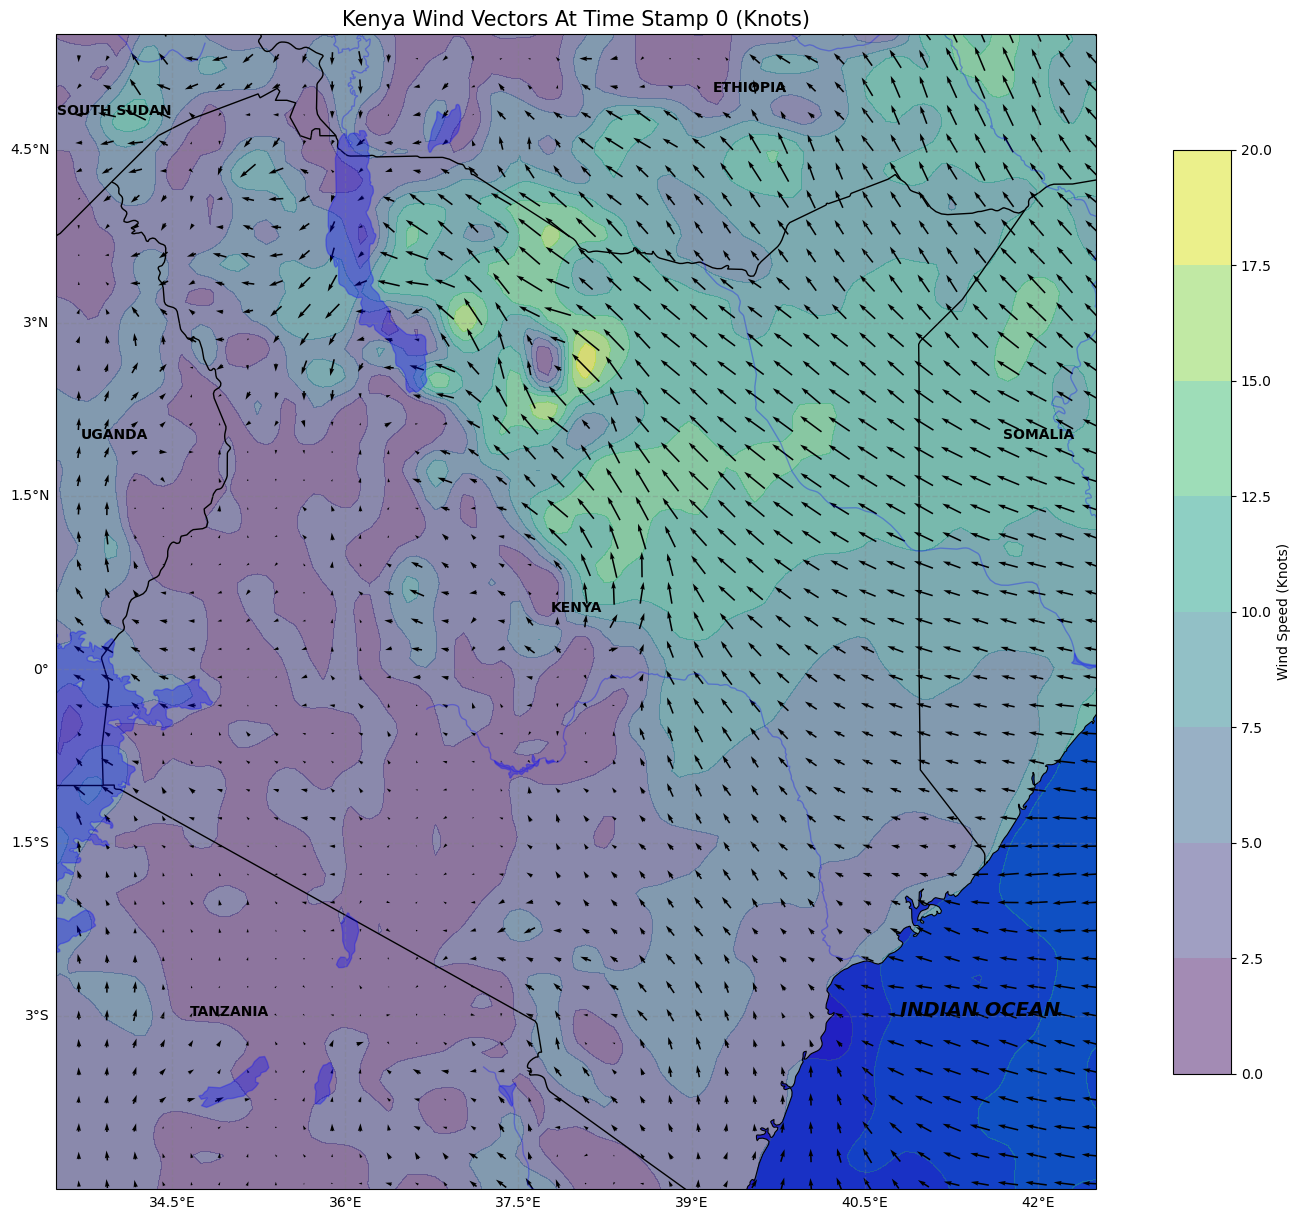

In [ ]:
# PLOTTING THE WIND VECTORS
fig = plt.figure(figsize=(20,15))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([33.5, 42.5, -4.5, 5.5], crs=ccrs.PlateCarree())  # Set the extent to cover Kenya

# 2. PLOT BACKGROUND (Optional: Keep the color for speed magnitude)
magnitude = np.sqrt(u_knots**2 + v_knots**2)
cp = plt.contourf(lon, lat, magnitude, transform=ccrs.PlateCarree(), cmap="viridis", alpha=0.5)

# 3. PLOT WIND VECTORS (The Arrows)
# We use [::n] to skip points so the map isn't crowded
skip = 3  # Adjust this value to show more or fewer arrows
q = ax.quiver(lon[::skip, ::skip], lat[::skip, ::skip],
              u_knots[::skip, ::skip], v_knots[::skip, ::skip],
              transform=ccrs.PlateCarree(),
              color='black',
              scale=500,        # Lower scale = longer arrows
              width=0.0015,     # Makes the arrow shaft thinner
              headwidth=3,      # Proportion of the head
              pivot='middle')   # Pivots arrow on the grid point


# 3. Add a Quiver Key (Essential for Professional Maps)
# This shows users what an arrow length actually represents in Knots
plt.quiverkey(q, 0.9, 0.05, 10, '10 Knots', labelpos='E', coordinates='figure')

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="Blue")
ax.add_feature(cfeature.LAKES, facecolor="Blue", edgecolor="blue", alpha=0.3)
ax.add_feature(cfeature.RIVERS, facecolor="Blue", edgecolor="blue", alpha=0.3)

# --- ADD GRIDLINES AND LABELS HERE ---
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.3, linestyle='--')

# Customize label appearance
gl.top_labels = False    # Turn off labels at the top
gl.right_labels = False  # Turn off labels on the right
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}
# -------------------------------------

# --- ADD COUNTRY AND OCEAN LABELS ---
# Syntax: ax.text(longitude, latitude, "Text", transform=ccrs.PlateCarree())
common_style = {
    'transform': ccrs.PlateCarree(), 
    'fontsize': 10, 
    'fontweight': 'bold', 
    'ha': 'center'
}

ax.text(38.0, 0.5, "KENYA", **common_style)
ax.text(42.0, 2.0, "SOMALIA", **common_style)
ax.text(39.5, 5.0, "ETHIOPIA", **common_style)
ax.text(34.0, 2.0, "UGANDA", **common_style)
ax.text(35.0, -3.0, "TANZANIA", **common_style)
ax.text(34.0, 4.8, "SOUTH SUDAN", **common_style)

# Indian Ocean label (slightly tilted for style)
ax.text(41.5, -3.0, "INDIAN OCEAN", transform=ccrs.PlateCarree(),
        fontsize=14, fontstyle='italic', fontweight='bold', color='black', ha='center')

# Title and Colorbar
plt.title("Kenya Wind Vectors At Time Stamp 0 (Knots)", fontsize=15)
plt.colorbar(cp, label="Wind Speed (Knots)", orientation="vertical", pad=0.05, aspect=16, shrink=0.8)

plt.show()


# ALL OF THE 20 TIME STEPS >> EACH TIME STEP WITH A PLOT - FOR LOOP

In [9]:
print(ds.XTIME.values)

['2026-03-20T06:00:00.000000000' '2026-03-20T07:00:17.999954223'
 '2026-03-20T08:00:35.999908447' '2026-03-20T09:00:00.000000000'
 '2026-03-20T10:00:18.000183105' '2026-03-20T11:00:36.000366210'
 '2026-03-20T12:00:00.000000000' '2026-03-20T13:00:17.999267578'
 '2026-03-20T14:00:36.000366210' '2026-03-20T15:00:00.000000000'
 '2026-03-20T16:00:17.999267578' '2026-03-20T17:00:35.998535156'
 '2026-03-20T18:00:00.000000000' '2026-03-20T19:00:17.999267578'
 '2026-03-20T20:00:35.998535156' '2026-03-20T21:00:00.000000000'
 '2026-03-20T22:00:17.999267578' '2026-03-20T23:00:35.998535156'
 '2026-03-21T00:00:00.000000000' '2026-03-21T01:00:18.002929687'
 '2026-03-21T02:00:35.998535156' '2026-03-21T03:00:00.000000000'
 '2026-03-21T04:00:18.002929687' '2026-03-21T05:00:35.998535156'
 '2026-03-21T06:00:00.000000000']


In [ ]:
import os

# Create an output directory for the frames
output_dir = "wind_maps"
os.makedirs(output_dir, exist_ok=True)

# Loop through all 25 time steps
for t in range(ds.dims['Time']):
    # 1. Extract data for the current time step
    u = ds.U10.isel(Time=t)
    v = ds.V10.isel(Time=t)
    lon = ds.XLONG.isel(Time=t)
    lat = ds.XLAT.isel(Time=t)
    
    # Get the timestamp string for titles and filenames
    time_str = str(ds.XTIME.values[t])[:19] 
    
    # Calculate magnitude and convert to knots 
    magnitude = np.sqrt(u**2 + v**2) * 1.94384 
    u_knots = u * 1.94384
    v_knots = v * 1.94384

    # 2. Setup Figure
    fig = plt.figure(figsize=(20, 15))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([33.5, 42.5, -4.5, 5.5], crs=ccrs.PlateCarree())

    # 3. Emphasized Background (plt.contourf)
    # Using 'magma' or 'nipy_spectral' for punchy colors
    levels = np.linspace(0, 30, 16) # Adjust 30 to your max expected wind speed
    cp = plt.contourf(lon, lat, magnitude, levels=levels, 
                      transform=ccrs.PlateCarree(), 
                      cmap="viridis", alpha=0.7, extend='max')

    # 4. Wind Vectors (Thin and Professional)
    skip = 3 
    q = ax.quiver(lon[::skip, ::skip], lat[::skip, ::skip], 
                  u_knots[::skip, ::skip], v_knots[::skip, ::skip],
                  transform=ccrs.PlateCarree(),
                  color='black', 
                  scale=500, 
                  width=0.0015, 
                  headwidth=3, 
                  pivot='middle')
    

    # 3. Add a Quiver Key (Essential for Professional Maps)
    # This shows users what an arrow length actually represents in Knots
    plt.quiverkey(q, 0.9, 0.05, 10, '10 Knots', labelpos='E', coordinates='figure')

    # 5. Features and Labels
    ax.add_feature(cfeature.BORDERS, edgecolor="black")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="Blue")
    ax.add_feature(cfeature.LAKES, facecolor="none", edgecolor="blue", alpha=0.3)
    ax.add_feature(cfeature.RIVERS, facecolor="none", edgecolor="blue",alpha=0.3)
    
    # Gridlines and Labels
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, 
                      linewidth=1, color='gray', alpha=0.3, linestyle='--')
    
    # Customize label appearance
    gl.top_labels = False    # Turn off labels at the top
    gl.right_labels = False  # Turn off labels on the right
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}


    # --- ADD COUNTRY AND OCEAN LABELS ---
    # Syntax: ax.text(longitude, latitude, "Text", transform=ccrs.PlateCarree())
    common_style = {
        'transform': ccrs.PlateCarree(), 
        'fontsize': 10, 
        'fontweight': 'bold', 
        'ha': 'center'
    }

    ax.text(38.0, 0.5, "KENYA", **common_style)
    ax.text(42.0, 2.0, "SOMALIA", **common_style)
    ax.text(39.5, 5.0, "ETHIOPIA", **common_style)
    ax.text(34.0, 2.0, "UGANDA", **common_style)
    ax.text(35.0, -3.0, "TANZANIA", **common_style)
    ax.text(34.0, 4.8, "SOUTH SUDAN", **common_style)

    # Indian Ocean label (slightly tilted for style)
    ax.text(41.5, -3.0, "INDIAN OCEAN", transform=ccrs.PlateCarree(),
        fontsize=14, fontstyle='italic', fontweight='bold', color='black', ha='center')

    # Dynamic Title
    plt.title(f"Kenya Wind Vectors | {time_str}", fontsize=18, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(cp, orientation="vertical", pad=0.05, aspect=20, shrink=0.8)
    cbar.set_label("Wind Speed (Knots)", weight='bold')

    # 6. Save and Close
    # Clean the time string for a filename
    file_name = f"wind_map_t{t:02d}.png"
    plt.savefig(os.path.join(output_dir, file_name), bbox_inches='tight', dpi=150)
    
    plt.close(fig) # Critical to prevent memory overflow
    print(f"Finished plotting time step {t}: {time_str}")

/tmp/ipykernel_54253/1667106028.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for t in range(ds.dims['Time']):


Finished plotting time step 0: 2026-03-20T06:00:00
Finished plotting time step 1: 2026-03-20T07:00:17
Finished plotting time step 2: 2026-03-20T08:00:35
Finished plotting time step 3: 2026-03-20T09:00:00
Finished plotting time step 4: 2026-03-20T10:00:18
Finished plotting time step 5: 2026-03-20T11:00:36
Finished plotting time step 6: 2026-03-20T12:00:00
Finished plotting time step 7: 2026-03-20T13:00:17
Finished plotting time step 8: 2026-03-20T14:00:36
Finished plotting time step 9: 2026-03-20T15:00:00
Finished plotting time step 10: 2026-03-20T16:00:17
Finished plotting time step 11: 2026-03-20T17:00:35
Finished plotting time step 12: 2026-03-20T18:00:00
Finished plotting time step 13: 2026-03-20T19:00:17
Finished plotting time step 14: 2026-03-20T20:00:35
Finished plotting time step 15: 2026-03-20T21:00:00
Finished plotting time step 16: 2026-03-20T22:00:17
Finished plotting time step 17: 2026-03-20T23:00:35
Finished plotting time step 18: 2026-03-21T00:00:00
Finished plotting time

# COMBINING THE TIME STEPS TO AN ANIMATIONS - VIDEO

## two methos can be used ""
    - using imageio
    - using celluloid

In [ ]:
# Method 1: Creating an MP4 or GIF with imageio
import imageio 
import glob

# 1. Get all the file paths in order
# Using sorted() is crucial to ensure t01 comes before t02
images = sorted(glob.glob(os.path.join(output_dir, "wind_map_t*.png")))

# 2. Define output filename
output_video = "kenya_wind_animation.mp4"

# 3. Create the animation
with imageio.get_writer(output_video, fps=1) as writer: # Adjust fps for speed
    for filename in images:
        image = imageio.imread(filename)
        writer.append_data(image)

print(f"Animation saved successfully as {output_video}")

/tmp/ipykernel_54253/2682247949.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1913, 1833) to (1920, 1840) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x5f2064701bc0] Stream #0: not enough frames to estimate rate; consider increasing probesize
[swscaler @ 0x5f2064719000] Warning: data is not aligned! This can lead to a speed loss


Animation saved successfully as kenya_wind_animation.mp4


# PLOTTING WIND MAP USING WIND BARBS

/home/erickwambugu/miniconda3/envs/wrf_venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


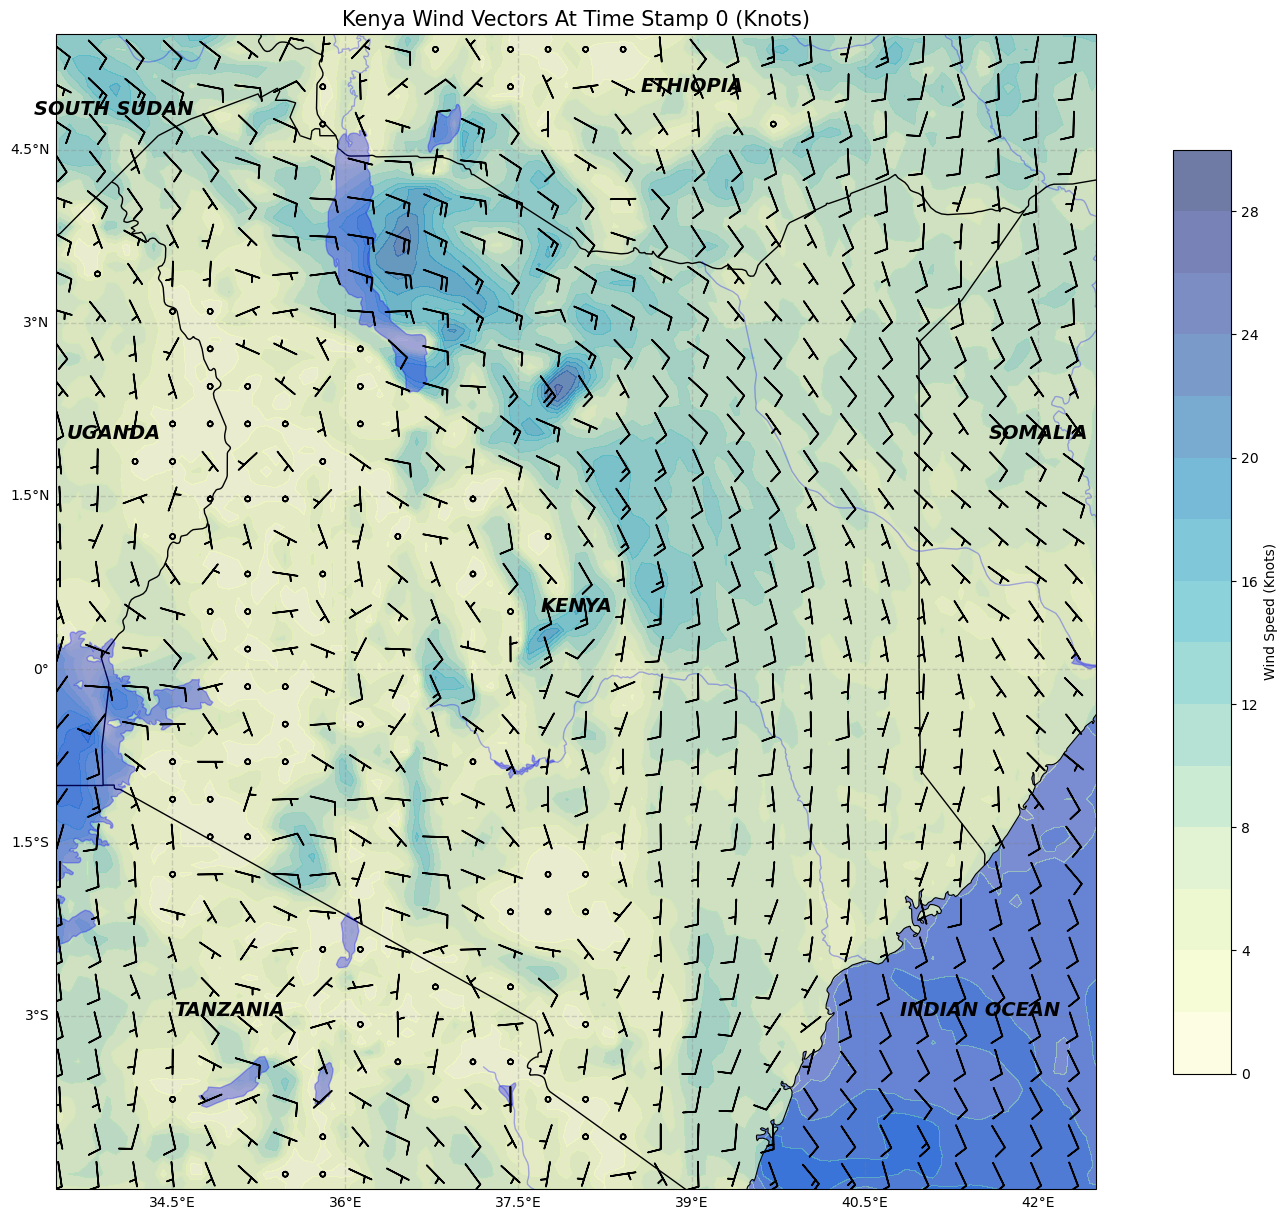

In [12]:
# PLOTTING THE WIND VECTORS
fig = plt.figure(figsize=(20,15))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([33.5, 42.5, -4.5, 5.5], crs=ccrs.PlateCarree())  # Set the extent to cover Kenya

# 2. PLOT BACKGROUND (Optional: Keep the color for speed magnitude)
magnitude = np.sqrt(u_knots**2 + v_knots**2)
level = np.arange(0, 31, 2)  # Adjust 30 to your max expected wind speed
cp = plt.contourf(lon, lat, magnitude, levels=level,transform=ccrs.PlateCarree(), cmap="YlGnBu", alpha=0.6)

# 3. PLOT WIND BARBS
# We use [::n] to skip points so the map isn't crowded
skip = 4  # Adjust this value to show more or fewer barbs
q = ax.barbs(lon[::skip, ::skip], lat[::skip, ::skip],
              u_knots[::skip, ::skip], v_knots[::skip, ::skip],
              transform=ccrs.PlateCarree(),
              color='black',
              length=6,       
              linewidth=1.2,     
              pivot='middle',
              sizes={'emptybarb': 0.1, 'spacing': 0.2, 'height': 0.5},
              zorder=5)  


# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="Blue", zorder=0)
ax.add_feature(cfeature.LAKES, facecolor="Blue", edgecolor="blue", alpha=0.3)
ax.add_feature(cfeature.RIVERS, facecolor="Blue", edgecolor="blue", alpha=0.3)

# --- ADD GRIDLINES AND LABELS HERE ---
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.3, linestyle='--')

# Customize label appearance
gl.top_labels = False    # Turn off labels at the top
gl.right_labels = False  # Turn off labels on the right
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}
# -------------------------------------

# --- ADD COUNTRY AND OCEAN LABELS ---
# Syntax: ax.text(longitude, latitude, "Text", transform=ccrs.PlateCarree())
common_style = {
    'transform': ccrs.PlateCarree(), 
    'fontsize': 14, 
    'fontstyle': 'italic',
    'fontweight': 'bold', 
    'ha': 'center'
}

ax.text(38.0, 0.5, "KENYA", **common_style)
ax.text(42.0, 2.0, "SOMALIA", **common_style)
ax.text(39.0, 5.0, "ETHIOPIA", **common_style)
ax.text(34.0, 2.0, "UGANDA", **common_style)
ax.text(35.0, -3.0, "TANZANIA", **common_style)
ax.text(34.0, 4.8, "SOUTH SUDAN", **common_style)
ax.text(41.5, -3.0, "INDIAN OCEAN", **common_style)

# Title and Colorbar
plt.title("Kenya Wind Vectors At Time Stamp 0 (Knots)", fontsize=15)
plt.colorbar(
    cp, 
    label="Wind Speed (Knots)", 
    orientation="vertical", 
    pad=0.05, aspect=16, shrink=0.8)

plt.show()